In [9]:
# let us make all the images 800X600 and save them
import cv2
import os
from pathlib import Path

def resize_images_in_folder(input_folder, output_folder, target_size=(800, 600)):
    """
    Scales (not crops) all images in a folder to fit within target_size.
    Maintains aspect ratio by padding if necessary.
    """
    input_path = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    for file in input_path.iterdir():
        if file.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp']:
            continue

        # Load image
        img = cv2.imread(str(file))
        if img is None:
            print(f"Skipping {file.name}: cannot read.")
            continue

        h, w = img.shape[:2]
        target_w, target_h = target_size

        # Compute scale factor to fit inside 800x600
        scale = min(target_w / w, target_h / h)
        new_w, new_h = int(w * scale), int(h * scale)

        # Resize image
        resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

        # Pad to exact target size (centered)
        top = (target_h - new_h) // 2
        bottom = target_h - new_h - top
        left = (target_w - new_w) // 2
        right = target_w - new_w - left
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=(0, 0, 0))

        # Save to output folder
        out_file = output_path / file.name
        cv2.imwrite(str(out_file), padded)

        #print(f"Processed: {file.name} → {out_file}")

# Example usage:
resize_images_in_folder(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\images", r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images", target_size=(800, 600))


In [12]:
import cv2
import numpy as np
import os
import pandas as pd
from pathlib import Path

def extract_hsv_std_features(input_folder, output_csv, grid_size=(8, 6)):
    """
    Extracts HSV mean and std features from each grid cell of all images in a folder.
    
    Parameters:
        input_folder (str): Path to folder containing images (800x600).
        output_csv (str): Path to save extracted features as CSV.
        grid_size (tuple): (cols, rows) to divide the image into equal grid blocks.
    """
    input_path = Path(input_folder)
    feature_list = []
    cols, rows = grid_size

    for file in input_path.iterdir():
        if file.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp']:
            continue

        img = cv2.imread(str(file))
        if img is None:
            print(f"Skipping {file.name}: cannot read.")
            continue

        # Convert to HSV
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h_img, w_img = hsv.shape[:2]

        # Calculate block size
        block_w = w_img // cols
        block_h = h_img // rows

        # Iterate through grid cells
        for r in range(rows):
            for c in range(cols):
                x_start = c * block_w
                y_start = r * block_h
                x_end = x_start + block_w
                y_end = y_start + block_h

                block = hsv[y_start:y_end, x_start:x_end]

                # Separate channels
                h_channel, s_channel, v_channel = cv2.split(block)

                # Compute mean and std for each channel
                features = {
                    'image_name': file.name,
                    'grid_row': r,
                    'grid_col': c,
                    'h_mean': np.mean(h_channel),
                    's_mean': np.mean(s_channel),
                    'v_mean': np.mean(v_channel),
                    'h_std': np.std(h_channel),
                    's_std': np.std(s_channel),
                    'v_std': np.std(v_channel),
                }

                feature_list.append(features)

        #print(f"Processed: {file.name}")

    # Convert to DataFrame
    df = pd.DataFrame(feature_list)

    # Save to CSV
    df.to_csv(output_csv, index=False)
    print(f"\n✅ Features saved to: {output_csv}")

    return df

# Example usage:
df_features = extract_hsv_std_features(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images", r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs.csv", grid_size=(8, 8))



✅ Features saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs.csv


In [14]:
# clustering on all the generated features
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
import os

def global_kmeans_segmentation(
    csv_path,
    image_folder,
    output_folder,
    grid_size=(8, 8),
    k=2
):
    """
    1️⃣ Loads all image-grid HSV+STD features from a CSV
    2️⃣ Trains one global KMeans(k)
    3️⃣ Updates CSV with consistent cluster labels
    4️⃣ Reconstructs each image with reddish shading on cluster 1
        and visible white grid lines
    5️⃣ Saves new segmented images and updated CSV
    """

    csv_path = Path(csv_path)
    image_folder = Path(image_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    # 1️⃣ Load features
    df = pd.read_csv(csv_path)
    print(f"✅ Loaded {len(df)} total grid blocks from {csv_path.name}")

    # 2️⃣ Prepare numeric features for clustering
    X = df[['h_mean', 's_mean', 'v_mean', 'h_std', 's_std', 'v_std']].values

    # 3️⃣ Train global KMeans
    print("⏳ Training global KMeans model...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X)
    print("✅ KMeans training complete.")
    print(df['cluster'].value_counts())

    # 4️⃣ Save updated CSV with new cluster column
    updated_csv = output_folder / "hsv_std_features_with_clusters.csv"
    df.to_csv(updated_csv, index=False)
    print(f"✅ Updated features saved to: {updated_csv}")

    # 5️⃣ Reconstruct each image with grid & shading
    cols, rows = grid_size
    for img_name in df['image_name'].unique():
        img_path = image_folder / img_name
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"⚠️ Skipping {img_name}: not found in {image_folder}")
            continue

        h_img, w_img = img.shape[:2]
        block_w = w_img // cols
        block_h = h_img // rows

        df_img = df[df['image_name'] == img_name]

        overlay = img.copy()
        for _, row in df_img.iterrows():
            r, c = int(row['grid_row']), int(row['grid_col'])
            x1, y1 = c * block_w, r * block_h
            x2, y2 = x1 + block_w, y1 + block_h

            if row['cluster'] == 1:
                cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 0, 255), -1)  # red fill

        # Blend overlay (light red tint)
        shaded = cv2.addWeighted(overlay, 0.25, img, 0.75, 0)

        # Draw grid lines (white)
        for r in range(1, rows):
            y = r * block_h
            cv2.line(shaded, (0, y), (w_img, y), (255, 255, 255), 1)
        for c in range(1, cols):
            x = c * block_w
            cv2.line(shaded, (x, 0), (x, h_img), (255, 255, 255), 1)

        out_file = output_folder / f"{Path(img_name).stem}_clustered.jpg"
        cv2.imwrite(str(out_file), shaded)
        #print(f"🖼️ Saved segmented image → {out_file}")

    print("\n🎯 All images processed with global KMeans segmentation.")
    return kmeans, df


# Example usage:
kmeans_model, df_updated = global_kmeans_segmentation(
     csv_path=r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs.csv",
     image_folder=r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images",
     output_folder=r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1",
     grid_size=(8, 8),
     k=2
 )


✅ Loaded 29760 total grid blocks from Outputs.csv
⏳ Training global KMeans model...
✅ KMeans training complete.
cluster
1    21157
0     8603
Name: count, dtype: int64
✅ Updated features saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs\hsv_std_features_with_clusters.csv

🎯 All images processed with global KMeans segmentation.


The outputs of trial 1 are very encouraging<br>
Now, I will try the attempt with further dividing the grids of 8x8 into 4x4 <br>
Let us call this trial 1.1

In [15]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
import os

# ============================================================
# 🔧 GLOBAL PATH HANDLES  — EDIT THESE 3 ONLY
# ============================================================
INPUT_FOLDER = Path(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images")
OUTPUT_CSV   = Path(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1.1\hsv_std_features_subcell.csv")
OUTPUT_FOLDER = Path(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1.1\SubcellClustered")

# ============================================================
# ⚙️ PARAMETERS
# ============================================================
GRID_SIZE = (8, 8)   # divide image into 8x8 major blocks
SUBGRID_SIZE = (4, 4)  # divide each block into 4x4 subcells
K = 2                 # KMeans clusters

# ============================================================
# 🧩 STEP 1 — EXTRACT HSV + STD FEATURES FROM SUBCELLS
# ============================================================

def extract_subcell_features(image_folder, grid_size=(8,8), subgrid_size=(4,4)):
    all_features = []
    for img_path in Path(image_folder).glob("*.jpg"):
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"⚠️ Skipping {img_path.name}, not found.")
            continue

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h_img, w_img = hsv.shape[:2]
        block_h = h_img // grid_size[0]
        block_w = w_img // grid_size[1]
        sub_h = block_h // subgrid_size[0]
        sub_w = block_w // subgrid_size[1]

        for i in range(grid_size[0]):         # major block rows
            for j in range(grid_size[1]):     # major block cols
                x1, y1 = j * block_w, i * block_h
                block = hsv[y1:y1+block_h, x1:x1+block_w]
                
                # iterate through subcells within this block
                for si in range(subgrid_size[0]):
                    for sj in range(subgrid_size[1]):
                        sx1 = x1 + sj * sub_w
                        sy1 = y1 + si * sub_h
                        sub = hsv[sy1:sy1+sub_h, sx1:sx1+sub_w]

                        h_mean, s_mean, v_mean = np.mean(sub[:,:,0]), np.mean(sub[:,:,1]), np.mean(sub[:,:,2])
                        h_std, s_std, v_std = np.std(sub[:,:,0]), np.std(sub[:,:,1]), np.std(sub[:,:,2])

                        all_features.append({
                            "image_name": img_path.name,
                            "block_row": i,
                            "block_col": j,
                            "sub_row": si,
                            "sub_col": sj,
                            "h_mean": h_mean,
                            "s_mean": s_mean,
                            "v_mean": v_mean,
                            "h_std": h_std,
                            "s_std": s_std,
                            "v_std": v_std
                        })

    df = pd.DataFrame(all_features)
    return df


# ============================================================
# 🧠 STEP 2 — GLOBAL KMEANS ON ALL SUBCELLS
# ============================================================

def run_global_kmeans(df, k=2):
    X = df[['h_mean', 's_mean', 'v_mean', 'h_std', 's_std', 'v_std']].values
    print("⏳ Running KMeans clustering...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X)
    print("✅ KMeans complete.")
    #print(df['cluster'].value_counts())
    return df, kmeans


# ============================================================
# 🎨 STEP 3 — RECONSTRUCT IMAGES (shade 8×8 blocks)
# ============================================================

def reconstruct_images(df, image_folder, output_folder, grid_size=(8,8), subgrid_size=(4,4)):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    for img_name in df['image_name'].unique():
        img_path = Path(image_folder) / img_name
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"⚠️ Skipping {img_name}, not found.")
            continue

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h_img, w_img = hsv.shape[:2]
        block_h = h_img // grid_size[0]
        block_w = w_img // grid_size[1]

        overlay = img.copy()
        df_img = df[df['image_name'] == img_name]

        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                # get subcells for this block
                subcells = df_img[(df_img['block_row'] == i) & (df_img['block_col'] == j)]
                if subcells.empty:
                    continue
                majority_cluster = int((subcells['cluster'].sum() / len(subcells)) >= 0.5)

                x1, y1 = j * block_w, i * block_h
                x2, y2 = x1 + block_w, y1 + block_h
                if majority_cluster == 1:
                    cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 0, 255), -1)

        # blend and draw 8×8 grid
        shaded = cv2.addWeighted(overlay, 0.25, img, 0.75, 0)
        for r in range(1, grid_size[0]):
            y = r * block_h
            cv2.line(shaded, (0, y), (w_img, y), (255, 255, 255), 1)
        for c in range(1, grid_size[1]):
            x = c * block_w
            cv2.line(shaded, (x, 0), (x, h_img), (255, 255, 255), 1)

        out_file = output_folder / f"{Path(img_name).stem}_block_clustered.jpg"
        cv2.imwrite(str(out_file), shaded)
        #print(f"🖼️ Saved segmented → {out_file}")


# ============================================================
# 🚀 MAIN PIPELINE
# ============================================================

def main():
    print("📂 Extracting subcell features...")
    df = extract_subcell_features(INPUT_FOLDER, GRID_SIZE, SUBGRID_SIZE)
    #print(f"✅ Extracted {len(df)} subcells from {df['image_name'].nunique()} images.")

    df, kmeans = run_global_kmeans(df, K)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"📁 Features + clusters saved to {OUTPUT_CSV}")

    reconstruct_images(df, INPUT_FOLDER, OUTPUT_FOLDER, GRID_SIZE, SUBGRID_SIZE)
    print("\n🎯 All images processed with hierarchical clustering.")

if __name__ == "__main__":
    main()


📂 Extracting subcell features...
⏳ Running KMeans clustering...
✅ KMeans complete.
📁 Features + clusters saved to C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1.1\hsv_std_features_subcell.csv

🎯 All images processed with hierarchical clustering.


### Trial 2- manual filter after Kmeans for green

In [2]:
# --- Manual HSV-based cluster correction ---
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

# 🔧 USER CONFIGURATION
csv_path = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1\Cluster_attempt_A_with_Basic features.csv"
image_folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images"
output_folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial2"

# specify which clusters to swap/check
x_cluster = 1   # e.g. cluster for green/non animal
y_cluster = 0   # e.g. cluster for animal

# Define HSV ranges for “green” reference (tune if needed)
GREEN_HUE_CENTER = 60     # 60° in HSV (0–179 scale in OpenCV)
HUE_TOLERANCE = 20        # how far from green we allow (±)
SAT_MIN = 40              # ignore very desaturated (grayish) pixels
VAL_MIN = 30

# I/O setup
output_folder = Path(output_folder)
output_folder.mkdir(parents=True, exist_ok=True)

# --- Step 1: Load features ---
df = pd.read_csv(csv_path)
print(f"✅ Loaded {len(df)} feature rows from {csv_path}")

# --- Step 2: Apply manual HSV overrides ---
def is_close_to_green(h, s, v):
    """Return True if pixel block is approximately green in HSV space."""
    hue_ok = abs(h - GREEN_HUE_CENTER) < HUE_TOLERANCE
    sat_ok = s > SAT_MIN
    val_ok = v > VAL_MIN
    return hue_ok and sat_ok and val_ok

def is_far_from_green(h, s, v):
    """Return True if pixel block is significantly away from green."""
    hue_far = abs(h - GREEN_HUE_CENTER) > (HUE_TOLERANCE * 1.2)
    return hue_far

# Make a copy for reference
df['cluster_original'] = df['cluster']

# Go row by row and apply overrides
changes = 0
for i, row in df.iterrows():
    h, s, v = row['h_mean'], row['s_mean'], row['v_mean']
    cl = row['cluster']

    # If cluster X but not green → likely misclustered → move to other cluster
    if cl == x_cluster and is_far_from_green(h, s, v):
        df.at[i, 'cluster'] = y_cluster
        changes += 1

    # If cluster Y but is green → likely vegetation → move to cluster X
    elif cl == y_cluster and is_close_to_green(h, s, v):
        df.at[i, 'cluster'] = x_cluster
        changes += 1

print(f"🔁 {changes} clusters manually corrected based on HSV color proximity to green.")

# --- Step 3: Save updated CSV ---
updated_csv = output_folder / "hsv_std_features_corrected.csv"
df.to_csv(updated_csv, index=False)
print(f"✅ Updated CSV saved → {updated_csv}")

# --- Step 4: Visualize corrected images ---
cols, rows = 8, 8
for img_name in df['image_name'].unique():
    img_path = Path(image_folder) / img_name
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"⚠️ Skipping {img_name} (not found)")
        continue

    h_img, w_img = img.shape[:2]
    block_w = w_img // cols
    block_h = h_img // rows
    df_img = df[df['image_name'] == img_name]

    overlay = img.copy()
    for _, row in df_img.iterrows():
        r, c = int(row['grid_row']), int(row['grid_col'])
        x1, y1 = c * block_w, r * block_h
        x2, y2 = x1 + block_w, y1 + block_h

        if row['cluster'] == x_cluster:
            cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 0, 255), -1)  # reddish fill

    shaded = cv2.addWeighted(overlay, 0.25, img, 0.75, 0)
    for r in range(1, rows):
        y = r * block_h
        cv2.line(shaded, (0, y), (w_img, y), (255, 255, 255), 1)
    for c in range(1, cols):
        x = c * block_w
        cv2.line(shaded, (x, 0), (x, h_img), (255, 255, 255), 1)

    out_file = output_folder / f"{Path(img_name).stem}_corrected.jpg"
    cv2.imwrite(str(out_file), shaded)

print("\n🎯 Manual color-based corrections complete. Check your output folder for new results.")


✅ Loaded 29760 feature rows from C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1\Cluster_attempt_A_with_Basic features.csv
🔁 16738 clusters manually corrected based on HSV color proximity to green.
✅ Updated CSV saved → C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial2\hsv_std_features_corrected.csv

🎯 Manual color-based corrections complete. Check your output folder for new results.


### Trial 3 - otsu

In [4]:
# ============================
# OTSU-BASED BINARY SEGMENTATION (for 8x8 grid only)
# ============================
# EDIT THESE HANDLES & PARAMS
INPUT_CSV = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1\Cluster_attempt_A_with_Basic features.csv"   # CSV with one row per 8x8 block
INPUT_IMAGE_FOLDER = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images"
OUTPUT_CSV = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Output_trial3\hsv_features_otsu.csv"
OUTPUT_IMAGE_FOLDER = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Output_trial3\output_images"

# Choose metric: 'v_std', 's_std', 'h_std', or 'combined'
FEATURE_METRIC = "combined"

# If combined, weights applied to [h_std, s_std, v_std]
COMBINED_WEIGHTS = (0.3, 0.4, 0.3)
"""
Give low weight to Hue (since green dominates color-wise and confuses segmentation),
moderate weight to Saturation (helps separate dull background),
and high weight to Value (captures brightness and texture).
"""

# Major grid dimensions
GRID_ROWS = 8
GRID_COLS = 8
# ============================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2

os.makedirs(OUTPUT_IMAGE_FOLDER, exist_ok=True)

# --- 1. Load CSV ---
df = pd.read_csv(INPUT_CSV)

required_cols = ['h_std', 's_std', 'v_std']
for c in required_cols:
    if c not in df.columns and FEATURE_METRIC == 'combined':
        raise ValueError(f"CSV missing required column '{c}' for combined metric.")

if FEATURE_METRIC not in ['h_std', 's_std', 'v_std', 'combined']:
    raise ValueError("FEATURE_METRIC must be one of 'h_std', 's_std', 'v_std', or 'combined'")

# --- 2. Compute scalar metric per grid cell ---
if FEATURE_METRIC == 'combined':
    w_h, w_s, w_v = COMBINED_WEIGHTS
    metric_vals = (w_h * df['h_std'].to_numpy()
                  + w_s * df['s_std'].to_numpy()
                  + w_v * df['v_std'].to_numpy())
else:
    metric_vals = df[FEATURE_METRIC].to_numpy()

# Scale to 0–255 for Otsu
minv, maxv = float(np.nanmin(metric_vals)), float(np.nanmax(metric_vals))
if maxv == minv:
    raise ValueError("All metric values identical; Otsu cannot compute threshold.")
metric_scaled = ((metric_vals - minv) / (maxv - minv) * 255.0).astype(np.uint8)

# --- 3. Compute Otsu threshold ---
otsu_value, otsu_thresh = cv2.threshold(metric_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
otsu_metric_thresh = (otsu_value / 255.0) * (maxv - minv) + minv

print(f"Computed Otsu threshold (scaled) = {otsu_value:.2f}; mapped metric threshold = {otsu_metric_thresh:.4f}")

# --- 4. Assign binary labels based on threshold ---
df['metric_value'] = metric_vals
df['metric_scaled'] = metric_scaled
df['otsu_label'] = (df['metric_value'] >= otsu_metric_thresh).astype(int)

# --- 5. Save updated CSV ---
Path(OUTPUT_CSV).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)
print(f"Updated CSV with Otsu labels saved to: {OUTPUT_CSV}")

# --- 6. Reconstruct images (8x8 grid) ---
# Detect column names for grid coords
block_row_col_names = None
for candidates in [('block_row','block_col'), ('grid_row','grid_col'), ('r','c'), ('row','col')]:
    if candidates[0] in df.columns and candidates[1] in df.columns:
        block_row_col_names = candidates
        break
if block_row_col_names is None:
    raise ValueError("Could not find block row/col columns in CSV. Expected one of: ('block_row','block_col'), ('grid_row','grid_col'), ('r','c'), ('row','col')")

block_row_name, block_col_name = block_row_col_names
print(f"Using grid coords: {block_row_name}, {block_col_name}")

# Iterate over each image
for img_name in df['image_name'].unique():
    img_path = Path(INPUT_IMAGE_FOLDER) / img_name
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Skipping missing image: {img_name}")
        continue

    h_img, w_img = img.shape[:2]
    block_h = h_img // GRID_ROWS
    block_w = w_img // GRID_COLS
    overlay = img.copy()

    df_img = df[df['image_name'] == img_name]

    for br in range(GRID_ROWS):
        for bc in range(GRID_COLS):
            subcell = df_img[(df_img[block_row_name] == br) & (df_img[block_col_name] == bc)]
            if subcell.empty:
                continue
            if int(subcell['otsu_label'].iloc[0]) == 1:
                x1, y1 = bc * block_w, br * block_h
                x2, y2 = x1 + block_w, y1 + block_h
                cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 0, 255), -1)  # RED for cluster 1

    # Blend overlay and draw grid
    result = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)
    for r in range(1, GRID_ROWS):
        y = r * block_h
        cv2.line(result, (0, y), (w_img, y), (255, 255, 255), 1)
    for c in range(1, GRID_COLS):
        x = c * block_w
        cv2.line(result, (x, 0), (x, h_img), (255, 255, 255), 1)

    out_path = Path(OUTPUT_IMAGE_FOLDER) / f"otsu_{Path(img_name).stem}.jpg"
    cv2.imwrite(str(out_path), result)

print(f"Otsu-based segmented images saved to: {OUTPUT_IMAGE_FOLDER}")


Computed Otsu threshold (scaled) = 79.00; mapped metric threshold = 26.4864
Updated CSV with Otsu labels saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Output_trial3\hsv_features_otsu.csv
Using grid coords: grid_row, grid_col
Otsu-based segmented images saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Output_trial3\output_images


### Short trial - Trial 4

In [18]:
# ========================================
# REGION GROWING SEGMENTATION + 8x8 GRID AGGREGATION
# ========================================

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import os
from collections import deque

# ========== EDIT THESE ==========
IMAGE_PATHS = [
    r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images\26102010062.jpg",
    r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images\CIMG0060.JPG",
    r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images\CIMG0118(2).JPG",
    r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images\CIMG0123(1).JPG",
    r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images\Rimg0149s.jpg",
]
OUTPUT_CSV = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial4\Regin_growing.csv"
OUTPUT_FOLDER = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial4"

GRID_ROWS = 8
GRID_COLS = 8
THRESH_HSV_DIST = 100.0   # adjust this for sensitivity (lower = tighter region)
# ========================================

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
records = []

def region_grow_hsv(img_hsv, seed_pt, thresh_dist):
    """
    Perform simple region growing from a seed point based on HSV color similarity.
    Returns binary mask (1 = region grown).
    """
    h, w = img_hsv.shape[:2]
    mask = np.zeros((h, w), np.uint8)

    seed_color = img_hsv[seed_pt[1], seed_pt[0]].astype(np.float32)
    q = deque([seed_pt])
    
    mask[seed_pt[1], seed_pt[0]] = 1

    directions = [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]

    while q:
        x, y = q.popleft()
        for dx, dy in directions:
            nx, ny = x+dx, y+dy
            if 0 <= nx < w and 0 <= ny < h and mask[ny, nx] == 0:
                diff = np.linalg.norm(img_hsv[ny, nx].astype(np.float32) - seed_color)
                if diff < thresh_dist:
                    mask[ny, nx] = 1
                    q.append((nx, ny))
    return mask

for img_path in IMAGE_PATHS:
    img = cv2.imread(img_path)
    if img is None:
        print(f"Skipping missing image: {img_path}")
        continue

    h, w = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    seed_pt = (w//2, h//2)

    print(f"Processing {Path(img_path).name} — seed @ {seed_pt}")

    # Region growing
    mask = region_grow_hsv(hsv, seed_pt, THRESH_HSV_DIST)

    # Grid aggregation
    block_h = h // GRID_ROWS
    block_w = w // GRID_COLS
    overlay = img.copy()

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            y1, y2 = r * block_h, (r + 1) * block_h
            x1, x2 = c * block_w, (c + 1) * block_w
            block = mask[y1:y2, x1:x2]
            mean_val = np.mean(block)
            label = 1 if mean_val >= 0.5 else 0
            records.append({
                "image_name": Path(img_path).name,
                "block_row": r,
                "block_col": c,
                "label": label
            })
            if label == 1:
                cv2.rectangle(overlay, (x1, y1), (x2, y2), (0,0,255), -1)

    # Blend result and draw grid lines
    result = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)
    for r in range(1, GRID_ROWS):
        y = r * block_h
        cv2.line(result, (0,y), (w,y), (255,255,255), 1)
    for c in range(1, GRID_COLS):
        x = c * block_w
        cv2.line(result, (x,0), (x,h), (255,255,255), 1)

    out_path = Path(OUTPUT_FOLDER) / f"regiongrow_{Path(img_path).stem}.jpg"
    cv2.imwrite(str(out_path), result)
    print(f"Saved segmented image: {out_path}")

# Save block-level labels
df = pd.DataFrame(records)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nAll block labels saved to: {OUTPUT_CSV}")


Processing 26102010062.jpg — seed @ (400, 300)
Saved segmented image: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial4\regiongrow_26102010062.jpg
Processing CIMG0060.JPG — seed @ (400, 300)
Saved segmented image: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial4\regiongrow_CIMG0060.jpg
Processing CIMG0118(2).JPG — seed @ (400, 300)
Saved segmented image: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial4\regiongrow_CIMG0118(2).jpg
Processing CIMG0123(1).JPG — seed @ (400, 300)
Saved segmented image: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial4\regiongrow_CIMG0123(1).jpg
Processing Rimg0149s.jpg — seed @ (400, 300)
Saved segmented image: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial4\regiongrow_Rimg0149s.jpg

All block labels saved to: C:\User

### trial 5- same as trial 1 but this time with RGB features

In [20]:
# ========================================
# RGB GRID FEATURE EXTRACTION + GLOBAL KMEANS SEGMENTATION
# ========================================

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
import os

# ====== 1️⃣ EDIT THESE HANDLES ======
INPUT_IMAGE_FOLDER = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images"
OUTPUT_FEATURE_CSV = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial5\metrics.csv"
OUTPUT_FOLDER = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial5\images"

GRID_SIZE = (8, 8)  # (cols, rows)
K_CLUSTERS = 2
# ====================================

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ====== 2️⃣ RGB Feature Extraction ======
def extract_rgb_std_features(input_folder, output_csv, grid_size=(8, 8)):
    input_path = Path(input_folder)
    feature_list = []
    cols, rows = grid_size

    for file in input_path.iterdir():
        if file.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp']:
            continue

        img = cv2.imread(str(file))
        if img is None:
            print(f"Skipping {file.name}: cannot read.")
            continue

        h_img, w_img = img.shape[:2]
        block_w = w_img // cols
        block_h = h_img // rows

        for r in range(rows):
            for c in range(cols):
                x_start = c * block_w
                y_start = r * block_h
                x_end = x_start + block_w
                y_end = y_start + block_h

                block = img[y_start:y_end, x_start:x_end]
                b_chan, g_chan, r_chan = cv2.split(block)

                features = {
                    'image_name': file.name,
                    'grid_row': r,
                    'grid_col': c,
                    'r_mean': np.mean(r_chan),
                    'g_mean': np.mean(g_chan),
                    'b_mean': np.mean(b_chan),
                    'r_std': np.std(r_chan),
                    'g_std': np.std(g_chan),
                    'b_std': np.std(b_chan),
                }

                feature_list.append(features)

    df = pd.DataFrame(feature_list)
    df.to_csv(output_csv, index=False)
    print(f"\n✅ RGB features saved to: {output_csv}")
    return df

# ====== 3️⃣ Global KMeans Segmentation ======
def global_kmeans_segmentation_rgb(
    csv_path,
    image_folder,
    output_folder,
    grid_size=(8, 8),
    k=2
):
    csv_path = Path(csv_path)
    image_folder = Path(image_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(csv_path)
    print(f"✅ Loaded {len(df)} total grid blocks from {csv_path.name}")

    X = df[['r_mean','g_mean','b_mean','r_std','g_std','b_std']].values

    print("⏳ Training global KMeans model...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X)
    print("✅ KMeans training complete.")
    print(df['cluster'].value_counts())

    updated_csv = output_folder / "rgb_features_with_clusters.csv"
    df.to_csv(updated_csv, index=False)
    print(f"✅ Updated features saved to: {updated_csv}")

    cols, rows = grid_size
    for img_name in df['image_name'].unique():
        img_path = image_folder / img_name
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"⚠️ Skipping {img_name}: not found")
            continue

        h_img, w_img = img.shape[:2]
        block_w = w_img // cols
        block_h = h_img // rows

        df_img = df[df['image_name'] == img_name]
        overlay = img.copy()
        for _, row in df_img.iterrows():
            r, c = int(row['grid_row']), int(row['grid_col'])
            x1, y1 = c * block_w, r * block_h
            x2, y2 = x1 + block_w, y1 + block_h

            if row['cluster'] == 1:
                cv2.rectangle(overlay, (x1, y1), (x2, y2), (0,0,255), -1)

        shaded = cv2.addWeighted(overlay, 0.25, img, 0.75, 0)
        for r in range(1, rows):
            y = r * block_h
            cv2.line(shaded, (0,y), (w_img,y), (255,255,255), 1)
        for c in range(1, cols):
            x = c * block_w
            cv2.line(shaded, (x,0), (x,h_img), (255,255,255), 1)

        out_file = output_folder / f"{Path(img_name).stem}_clustered.jpg"
        cv2.imwrite(str(out_file), shaded)

    print("\n🎯 All images processed with global RGB KMeans segmentation.")
    return kmeans, df

# ====== 4️⃣ Run pipeline ======
df_rgb_features = extract_rgb_std_features(INPUT_IMAGE_FOLDER, OUTPUT_FEATURE_CSV, grid_size=GRID_SIZE)
kmeans_model_rgb, df_rgb_clustered = global_kmeans_segmentation_rgb(
    csv_path=OUTPUT_FEATURE_CSV,
    image_folder=INPUT_IMAGE_FOLDER,
    output_folder=OUTPUT_FOLDER,
    grid_size=GRID_SIZE,
    k=K_CLUSTERS
)



✅ RGB features saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial5\metrics.csv
✅ Loaded 29760 total grid blocks from metrics.csv
⏳ Training global KMeans model...
✅ KMeans training complete.
cluster
0    19565
1    10195
Name: count, dtype: int64
✅ Updated features saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial5\images\rgb_features_with_clusters.csv

🎯 All images processed with global RGB KMeans segmentation.


### dendogram to gauge better

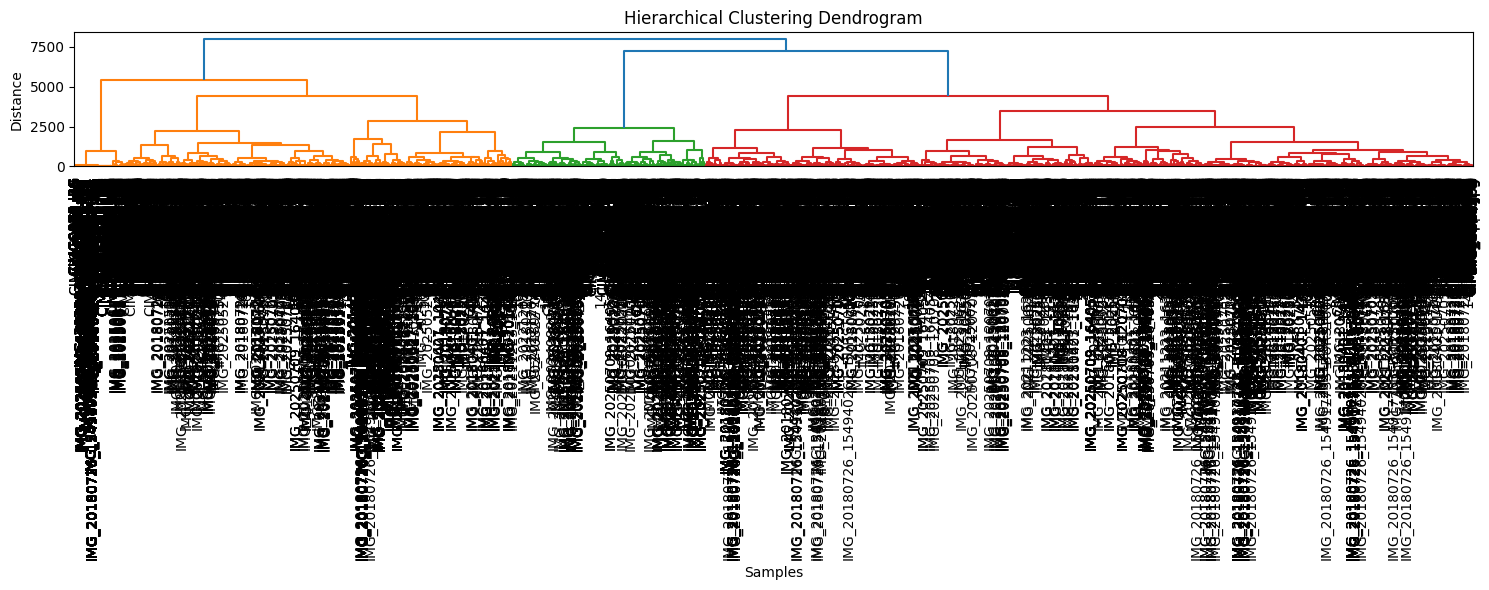

In [22]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# ========== EDIT THESE HANDLES ==========
CSV_FILE = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial1\Cluster_attempt_A_with_Basic features.csv"
FEATURE_COLUMNS = ['h_mean', 's_mean', 'v_mean', 'h_std', 's_std', 'v_std']  # columns to use for clustering
PLOT_TITLE = "Hierarchical Clustering Dendrogram"
# ========================================

# 1️⃣ Load CSV
df = pd.read_csv(CSV_FILE)
for col in FEATURE_COLUMNS:
    if col not in df.columns:
        raise ValueError(f"CSV is missing required column: {col}")

X = df[FEATURE_COLUMNS].values

# 2️⃣ Hierarchical clustering (Ward linkage recommended for Euclidean distance)
Z = linkage(X, method='ward')

# 3️⃣ Plot dendrogram
plt.figure(figsize=(15, 6))
dendrogram(Z,
           leaf_rotation=90,  # rotate x-axis labels
           leaf_font_size=10,
           labels=df['image_name'].values if 'image_name' in df.columns else None,
           color_threshold=None
          )
plt.title(PLOT_TITLE)
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


### Trial 6: A final trial with all possible input features, if this does not work, we need to do something radical

In [2]:
import cv2
import numpy as np
import pandas as pd
import os
from pathlib import Path
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from tqdm import tqdm

# ========================== CONFIGURATION ==========================
input_folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images"
output_csv = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial6\ALL_feature_noSIFT.csv"
grid_size = (8, 8)

# LBP parameters
lbp_radius = 1
lbp_points = 8 * lbp_radius

# HOG parameters
hog_pixels_per_cell = (8, 8)
hog_cells_per_block = (1, 1)

# GLCM parameters
glcm_distances = [1]
glcm_angles = [0]
# ===================================================================


def extract_features_from_block(block_bgr):
    """Extract HSV, HOG, LBP, and GLCM features from a given block."""
    features = {}

    # --- HSV mean and std ---
    hsv = cv2.cvtColor(block_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    features["H_mean"] = np.mean(h)
    features["S_mean"] = np.mean(s)
    features["V_mean"] = np.mean(v)
    features["H_std"] = np.std(h)
    features["S_std"] = np.std(s)
    features["V_std"] = np.std(v)

    # --- Convert to grayscale once ---
    gray = cv2.cvtColor(block_bgr, cv2.COLOR_BGR2GRAY)
    gray_norm = gray / 255.0  # normalize for skimage features

    # --- HOG ---
    hog_features = hog(
        gray_norm,
        pixels_per_cell=hog_pixels_per_cell,
        cells_per_block=hog_cells_per_block,
        feature_vector=True
    )
    features["HOG"] = np.mean(hog_features)

    # --- LBP ---
    lbp = local_binary_pattern(gray_norm, lbp_points, lbp_radius, method="uniform")
    features["LBP_mean"] = np.mean(lbp)
    features["LBP_std"] = np.std(lbp)

    # --- GLCM ---
    gray_8bit = gray.astype(np.uint8)
    glcm = graycomatrix(
        gray_8bit, 
        distances=glcm_distances, 
        angles=glcm_angles,
        symmetric=True, 
        normed=True
    )
    features["GLCM_contrast"] = graycoprops(glcm, 'contrast').mean()
    features["GLCM_dissimilarity"] = graycoprops(glcm, 'dissimilarity').mean()
    features["GLCM_homogeneity"] = graycoprops(glcm, 'homogeneity').mean()
    features["GLCM_ASM"] = graycoprops(glcm, 'ASM').mean()

    return features


def extract_image_features(input_folder, output_csv, grid_size=(8, 8)):
    input_path = Path(input_folder)
    all_features = []
    cols, rows = grid_size

    for file in tqdm(list(input_path.iterdir()), desc="Processing images"):
        if file.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp']:
            continue

        img = cv2.imread(str(file))
        if img is None:
            print(f"Skipping {file.name}: cannot read.")
            continue

        h_img, w_img = img.shape[:2]
        block_w = w_img // cols
        block_h = h_img // rows

        for r in range(rows):
            for c in range(cols):
                x_start = c * block_w
                y_start = r * block_h
                block = img[y_start:y_start + block_h, x_start:x_start + block_w]

                feats = extract_features_from_block(block)
                feats["image_name"] = file.name
                feats["grid_row"] = r
                feats["grid_col"] = c
                all_features.append(feats)

    df = pd.DataFrame(all_features)
    df.to_csv(output_csv, index=False)
    print(f"\n✅ Features saved to: {output_csv}")
    return df


# ======================= RUN EXTRACTION ===========================
df = extract_image_features(input_folder, output_csv, grid_size)


Processing images: 100%|█████████████████████████████████████████████████████████████| 465/465 [03:35<00:00,  2.15it/s]



✅ Features saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial6\ALL_feature_noSIFT.csv


In [3]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from tqdm import tqdm
import os

# ==================== USER CONFIGURATION ====================
csv_path = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial6\ALL_feature_noSIFT.csv"                # e.g., "Scaled_images/ALL_feature_noSIFT.csv"
image_folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images"   # e.g., "Scaled_images/"
master_output = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial6" # e.g., "Cluster_Results/"
grid_size = (8, 8)
shade_color = (0, 0, 255)  # Red in BGR
alpha = 0.4                # Transparency for shading
# ===========================================================

# Load CSV
df = pd.read_csv(csv_path)
cols_features = [col for col in df.columns if col not in ['image_name','grid_row','grid_col']]

# Ensure output master folder exists
Path(master_output).mkdir(parents=True, exist_ok=True)

# Store results
results_table = []

# Iterate over features one by one
for feature_name in cols_features:
    print(f"\n--- Processing Feature: {feature_name} ---")

    # Extract feature column and standardize
    X = df[[feature_name]].values
    X = StandardScaler().fit_transform(X)

    # Run KMeans
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # Silhouette Score
    if len(np.unique(cluster_labels)) > 1:
        score = silhouette_score(X, cluster_labels)
    else:
        score = np.nan
    results_table.append((feature_name, score))
    print(f"Silhouette Score: {score:.4f}")

    # Add cluster labels to dataframe
    df['cluster'] = cluster_labels

    # --- Visualization per image ---
    feature_output_folder = Path(master_output) / feature_name
    feature_output_folder.mkdir(parents=True, exist_ok=True)

    for img_name in df['image_name'].unique():
        img_path = Path(image_folder) / img_name
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Skipping {img_name}, cannot read.")
            continue

        h_img, w_img = img.shape[:2]
        cols, rows = grid_size
        block_w = w_img // cols
        block_h = h_img // rows

        img_blocks = df[df['image_name'] == img_name]

        overlay = img.copy()

        for _, row in img_blocks.iterrows():
            r = int(row['grid_row'])
            c = int(row['grid_col'])
            cluster = int(row['cluster'])

            if cluster == 1:
                y_start = r * block_h
                x_start = c * block_w
                y_end = y_start + block_h
                x_end = x_start + block_w

                cv2.rectangle(
                    overlay,
                    (x_start, y_start),
                    (x_end, y_end),
                    shade_color,
                    -1
                )

        # Blend overlay
        cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

        # Draw grid lines
        for r in range(1, rows):
            cv2.line(img, (0, r*block_h), (w_img, r*block_h), (255,255,255), 1)
        for c in range(1, cols):
            cv2.line(img, (c*block_w,0), (c*block_w,h_img), (255,255,255), 1)

        # Save visualized image
        out_path = feature_output_folder / img_name
        cv2.imwrite(str(out_path), img)

# --- Print Summary Table ---
print("\n\n===== Silhouette Scores per Feature =====")
print("{:<20} {:<15}".format("Feature", "Silhouette Score"))
for feat, score in results_table:
    print(f"{feat:<20} {score:<15.4f}")




--- Processing Feature: H_mean ---
Silhouette Score: 0.6898

--- Processing Feature: S_mean ---
Silhouette Score: 0.5795

--- Processing Feature: V_mean ---
Silhouette Score: 0.5595

--- Processing Feature: H_std ---
Silhouette Score: 0.7081

--- Processing Feature: S_std ---
Silhouette Score: 0.6227

--- Processing Feature: V_std ---
Silhouette Score: 0.5809

--- Processing Feature: HOG ---
Silhouette Score: 0.8900

--- Processing Feature: LBP_mean ---
Silhouette Score: 0.8373

--- Processing Feature: LBP_std ---
Silhouette Score: 0.7904

--- Processing Feature: GLCM_contrast ---
Silhouette Score: 0.7526

--- Processing Feature: GLCM_dissimilarity ---
Silhouette Score: 0.6011

--- Processing Feature: GLCM_homogeneity ---
Silhouette Score: 0.7147

--- Processing Feature: GLCM_ASM ---
Silhouette Score: 0.9593


===== Silhouette Scores per Feature =====
Feature              Silhouette Score
H_mean               0.6898         
S_mean               0.5795         
V_mean               0.

In [5]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

# ==================== USER CONFIGURATION ====================
csv_path = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial6\ALL_feature_noSIFT.csv"
image_folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images"
master_output = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial6.2"
grid_size = (8, 8)
shade_color = (0, 0, 255)  # Red in BGR
alpha = 0.4                # Transparency
features_to_use = ['GLCM_dissimilarity','GLCM_contrast']#, 'H_mean','H_std','V_mean','V_std','S_mean','S_std','GLCM_contrast']
# ===========================================================

# Load CSV
df = pd.read_csv(csv_path)

# Extract and scale features
X = df[features_to_use].values
X = StandardScaler().fit_transform(X)

# Run KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# Silhouette Score
if len(np.unique(df['cluster'])) > 1:
    score = silhouette_score(X, df['cluster'])
else:
    score = np.nan
print(f"Silhouette Score for selected features: {score:.4f}")

# Ensure output folder exists
Path(master_output).mkdir(parents=True, exist_ok=True)

# Visualization per image
for img_name in df['image_name'].unique():
    img_path = Path(image_folder) / img_name
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Skipping {img_name}, cannot read.")
        continue

    h_img, w_img = img.shape[:2]
    cols, rows = grid_size
    block_w = w_img // cols
    block_h = h_img // rows

    overlay = img.copy()
    img_blocks = df[df['image_name'] == img_name]

    for _, row in img_blocks.iterrows():
        r = int(row['grid_row'])
        c = int(row['grid_col'])
        cluster = int(row['cluster'])

        if cluster == 1:
            y_start = r * block_h
            x_start = c * block_w
            y_end = y_start + block_h
            x_end = x_start + block_w

            cv2.rectangle(
                overlay,
                (x_start, y_start),
                (x_end, y_end),
                shade_color,
                -1
            )

    # Blend overlay
    cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

    # Draw grid lines
    for r in range(1, rows):
        cv2.line(img, (0, r*block_h), (w_img, r*block_h), (255,255,255), 1)
    for c in range(1, cols):
        cv2.line(img, (c*block_w,0), (c*block_w,h_img), (255,255,255), 1)

    # Save visualized image
    out_path = Path(master_output) / img_name
    cv2.imwrite(str(out_path), img)

print(f"\n✅ All images saved to: {master_output}")


Silhouette Score for selected features: 0.6431

✅ All images saved to: C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Outputs_trial6.2


### retry with a whole set of new features

In [1]:
import pandas as pd
df= pd.read_csv(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\all_features_extended_rgb_glcm_saliency.csv")

In [4]:
df.head()
df.columns

Index(['filename', 'grid_index', 'sobel_mean_x', 'sobel_mean_y',
       'sobel_mean_mag', 'sobel_std_x', 'sobel_std_y', 'sobel_std_mag',
       'lap_mean', 'lap_std', 'lap_skew', 'lbp_bin_0', 'lbp_bin_1',
       'lbp_bin_2', 'lbp_bin_3', 'lbp_bin_4', 'lbp_bin_5', 'lbp_bin_6',
       'lbp_bin_7', 'lbp_bin_8', 'h_mean', 's_mean', 'v_mean', 'h_std',
       's_std', 'v_std', 'gabor_mean_f0.1', 'gabor_std_f0.1',
       'gabor_mean_f0.2', 'gabor_std_f0.2', 'gabor_mean_f0.3',
       'gabor_std_f0.3', 'gabor_mean_f0.4', 'gabor_std_f0.4', 'glcm_contrast',
       'glcm_homogeneity', 'glcm_energy', 'glcm_correlation',
       'glcm_dissimilarity', 'r_over_g_mean', 'r_over_b_mean', 'g_over_b_mean',
       'r_over_g_std', 'r_over_b_std', 'g_over_b_std', 'saliency_mean',
       'saliency_std'],
      dtype='object')

In [5]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
import numpy as np

def calculate_and_filter_vif_dynamic(df_input, exclude_cols=['filename', 'grid_index'], vif_threshold=10):
    """
    Dynamically selects feature columns, calculates VIF, and identifies highly 
    correlated ones.
    """
    # 1. Dynamically select features
    all_columns = df_input.columns.tolist()
    feature_cols = [col for col in all_columns if col not in exclude_cols]
    
    if not feature_cols:
        print("Error: No feature columns found after excluding identifiers.")
        return None, []

    print(f"✅ Calculating VIF for {len(feature_cols)} features...")

    # 2. Select and standardize the features
    X = df_input[feature_cols].copy()
    
    # Handle potential non-finite values (NaN, Inf) which break VIF calculation
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    
    # Ensure there are still columns after dropping NaNs
    if X.empty:
        print("Error: DataFrame became empty after dropping non-finite values.")
        return None, []
        
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    
    # 3. Add a constant term for the VIF calculation
    X_with_const = add_constant(X_scaled, has_constant='add')
    
    # 4. Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_with_const.columns
    # The VIF function needs the numpy array of values
    vif_data["VIF"] = [
        variance_inflation_factor(X_with_const.values, i) 
        for i in range(X_with_const.shape[1])
    ]

    # 5. Clean up results
    vif_data = vif_data[vif_data['feature'] != 'const']
    vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
    
    # 6. Identify features for removal
    high_vif_features = vif_data[vif_data['VIF'] >= vif_threshold]['feature'].tolist()
    
    return vif_data, high_vif_features

# ----------------- EXECUTION -----------------

# 1. Ensure your 'df' is loaded and ready with the columns (AS YOU CONFIRMED)
#    (Example placeholder for demonstration, replace with your actual df)
# df = ... your loaded DataFrame ...

# 2. Calculate VIFs using the dynamic selection function
vif_results, features_to_consider_removing = calculate_and_filter_vif_dynamic(
    df, 
    vif_threshold=10 
)

if vif_results is not None:
    print("\n--- 📊 VIF Calculation Results (VIF >= 10 are highly correlated) ---")
    print(vif_results.head(15).to_markdown(index=False)) # Display top 15 results

    print("\n--- 🗑️ Features with VIF >= 10 (Candidates for Removal) ---")
    print(features_to_consider_removing)

✅ Calculating VIF for 45 features...

--- 📊 VIF Calculation Results (VIF >= 10 are highly correlated) ---
| feature         |           VIF |
|:----------------|--------------:|
| lbp_bin_8       |   1.1259e+14  |
| lbp_bin_4       |   6.5746e+13  |
| lbp_bin_5       |   2.18621e+13 |
| lbp_bin_0       |   1.22881e+13 |
| lbp_bin_3       |   1.13584e+13 |
| lbp_bin_1       |   5.94142e+12 |
| lbp_bin_7       |   4.04818e+12 |
| lbp_bin_2       |   2.60248e+12 |
| lbp_bin_6       |   2.08307e+12 |
| gabor_mean_f0.3 | 949.144       |
| gabor_std_f0.3  | 818.607       |
| gabor_mean_f0.2 | 482.945       |
| gabor_std_f0.2  | 435.964       |
| gabor_mean_f0.4 | 364.356       |
| gabor_std_f0.4  | 299.105       |

--- 🗑️ Features with VIF >= 10 (Candidates for Removal) ---
['lbp_bin_8', 'lbp_bin_4', 'lbp_bin_5', 'lbp_bin_0', 'lbp_bin_3', 'lbp_bin_1', 'lbp_bin_7', 'lbp_bin_2', 'lbp_bin_6', 'gabor_mean_f0.3', 'gabor_std_f0.3', 'gabor_mean_f0.2', 'gabor_std_f0.2', 'gabor_mean_f0.4', 'gabor_std

In [24]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
import numpy as np

def calculate_and_filter_vif_dynamic(df_input, exclude_cols=['filename', 'grid_index','lbp_bin_8','gabor_mean_f0.3', 'gabor_std_f0.3', 'sobel_mean_mag'
                                                            , 'gabor_mean_f0.2', 'lbp_bin_0', 'gabor_std_f0.4', 'sobel_std_mag', 'glcm_dissimilarity'
                                                            , 'gabor_std_f0.1', 'glcm_homogeneity', 'r_over_b_mean', 'lap_std', 'lbp_bin_1', 'gabor_mean_f0.4'
                                                            , 'gabor_mean_f0.1', 'lbp_bin_4'], vif_threshold=10):
    """
    Dynamically selects feature columns, calculates VIF, and identifies highly 
    correlated ones.
    """
    # 1. Dynamically select features
    all_columns = df_input.columns.tolist()
    feature_cols = [col for col in all_columns if col not in exclude_cols]
    
    if not feature_cols:
        print("Error: No feature columns found after excluding identifiers.")
        return None, []

    print(f"✅ Calculating VIF for {len(feature_cols)} features...")

    # 2. Select and standardize the features
    X = df_input[feature_cols].copy()
    
    # Handle potential non-finite values (NaN, Inf) which break VIF calculation
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    
    # Ensure there are still columns after dropping NaNs
    if X.empty:
        print("Error: DataFrame became empty after dropping non-finite values.")
        return None, []
        
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    
    # 3. Add a constant term for the VIF calculation
    X_with_const = add_constant(X_scaled, has_constant='add')
    
    # 4. Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_with_const.columns
    # The VIF function needs the numpy array of values
    vif_data["VIF"] = [
        variance_inflation_factor(X_with_const.values, i) 
        for i in range(X_with_const.shape[1])
    ]

    # 5. Clean up results
    vif_data = vif_data[vif_data['feature'] != 'const']
    vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
    
    # 6. Identify features for removal
    high_vif_features = vif_data[vif_data['VIF'] >= vif_threshold]['feature'].tolist()
    
    return vif_data, high_vif_features

# ----------------- EXECUTION -----------------

# 1. Ensure your 'df' is loaded and ready with the columns (AS YOU CONFIRMED)
#    (Example placeholder for demonstration, replace with your actual df)
# df = ... your loaded DataFrame ...

# 2. Calculate VIFs using the dynamic selection function
vif_results, features_to_consider_removing = calculate_and_filter_vif_dynamic(
    df, 
    vif_threshold=10 
)

if vif_results is not None:
    print("\n--- 📊 VIF Calculation Results (VIF >= 10 are highly correlated) ---")
    print(vif_results.head(15).to_markdown(index=False)) # Display top 15 results

    print("\n--- 🗑️ Features with VIF >= 10 (Candidates for Removal) ---")
    print(features_to_consider_removing)

✅ Calculating VIF for 28 features...

--- 📊 VIF Calculation Results (VIF >= 10 are highly correlated) ---
| feature          |     VIF |
|:-----------------|--------:|
| lbp_bin_5        | 8.8665  |
| gabor_std_f0.2   | 8.80104 |
| lbp_bin_3        | 8.38938 |
| g_over_b_std     | 8.05707 |
| glcm_correlation | 6.72069 |
| lbp_bin_2        | 6.36415 |
| sobel_std_x      | 6.31233 |
| sobel_std_y      | 5.61747 |
| lbp_bin_7        | 5.32698 |
| glcm_contrast    | 5.29935 |
| r_over_g_std     | 4.84776 |
| r_over_b_std     | 4.63821 |
| g_over_b_mean    | 3.94357 |
| r_over_g_mean    | 3.89958 |
| v_std            | 3.70571 |

--- 🗑️ Features with VIF >= 10 (Candidates for Removal) ---
[]


In [25]:
import pandas as pd

# List of all columns you want to drop
COLUMNS_TO_DROP = [
    'lbp_bin_8', 'gabor_mean_f0.3', 'gabor_std_f0.3', 'sobel_mean_mag',
    'gabor_mean_f0.2', 'lbp_bin_0', 'gabor_std_f0.4', 'sobel_std_mag', 'glcm_dissimilarity',
    'gabor_std_f0.1', 'glcm_homogeneity', 'r_over_b_mean', 'lap_std', 'lbp_bin_1', 'gabor_mean_f0.4',
    'gabor_mean_f0.1', 'lbp_bin_4'
]

# Assuming your original DataFrame is named 'df'
try:
    # Create the new DataFrame by dropping the specified columns
    df_processed = df.drop(columns=COLUMNS_TO_DROP)
    
    print(f"✅ Successfully dropped {len(COLUMNS_TO_DROP)} features.")
    print(f"Original feature count (excluding identifiers): 45")
    print(f"New feature count (excluding identifiers): {len(df_processed.columns) - 2}")
    print("New DataFrame 'df_processed' created.")

except NameError:
    print("Error: The DataFrame 'df' was not found. Please ensure your original data is loaded into a variable named 'df'.")
except KeyError as e:
    print(f"Error: One or more columns to drop were not found in the DataFrame: {e}")

✅ Successfully dropped 17 features.
Original feature count (excluding identifiers): 45
New feature count (excluding identifiers): 28
New DataFrame 'df_processed' created.


In [27]:
import pandas as pd

# Load the labels data (the wide format file)
df_labels_wide = pd.read_excel(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\dino_clusters.xlsx")

# 1. Transform the labels DataFrame from wide to long format (Melt/Unpivot)
# The 'id_vars' are the columns to keep as identifiers ('filename')
id_vars = ['filename']
# The 'value_vars' are the columns to unpivot ('block_0' to 'block_63')
value_vars = [col for col in df_labels_wide.columns if col.startswith('block_')]

df_labels_long = pd.melt(
    df_labels_wide,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='block_col', # Temporary column to hold the block name
    value_name='label' # The label (0 or 1) is now in this column
)

# 2. Create the 'grid_index' key for merging
# Extract the number from 'block_X' (e.g., 'block_0' -> 0)
df_labels_long['grid_index'] = df_labels_long['block_col'].str.split('_').str[1].astype(int)

# Drop the temporary block column
df_labels_long = df_labels_long.drop(columns=['block_col'])


# 3. Merge the feature DataFrame (df_processed) and the unpivoted labels
MERGE_KEYS = ['filename', 'grid_index']

# Assuming df_processed is the DataFrame containing your pruned features
df_labeled = pd.merge(
    df_processed,
    df_labels_long,
    on=MERGE_KEYS,
    how='inner' # Ensures we only keep rows present in BOTH files
)

# Display the result (replace df_processed with df_labeled for further steps)
print("Merged DataFrame 'df_labeled' created.")
print(df_labeled.head().to_markdown(index=False))

Merged DataFrame 'df_labeled' created.
| filename                   |   grid_index |   sobel_mean_x |   sobel_mean_y |   sobel_std_x |   sobel_std_y |   lap_mean |   lap_skew |   lbp_bin_2 |   lbp_bin_3 |   lbp_bin_5 |   lbp_bin_6 |   lbp_bin_7 |   h_mean |   s_mean |   v_mean |   h_std |   s_std |   v_std |   gabor_std_f0.2 |   glcm_contrast |   glcm_energy |   glcm_correlation |   r_over_g_mean |   g_over_b_mean |   r_over_g_std |   r_over_b_std |   g_over_b_std |   saliency_mean |   saliency_std |   label |
|:---------------------------|-------------:|---------------:|---------------:|--------------:|--------------:|-----------:|-----------:|------------:|------------:|------------:|------------:|------------:|---------:|---------:|---------:|--------:|--------:|--------:|-----------------:|----------------:|--------------:|-------------------:|----------------:|----------------:|---------------:|---------------:|---------------:|----------------:|---------------:|--------:|
| IMG_2

In [28]:
df_labeled.columns

Index(['filename', 'grid_index', 'sobel_mean_x', 'sobel_mean_y', 'sobel_std_x',
       'sobel_std_y', 'lap_mean', 'lap_skew', 'lbp_bin_2', 'lbp_bin_3',
       'lbp_bin_5', 'lbp_bin_6', 'lbp_bin_7', 'h_mean', 's_mean', 'v_mean',
       'h_std', 's_std', 'v_std', 'gabor_std_f0.2', 'glcm_contrast',
       'glcm_energy', 'glcm_correlation', 'r_over_g_mean', 'g_over_b_mean',
       'r_over_g_std', 'r_over_b_std', 'g_over_b_std', 'saliency_mean',
       'saliency_std', 'label'],
      dtype='object')

Starting analysis on 28 features...
Features standardized.


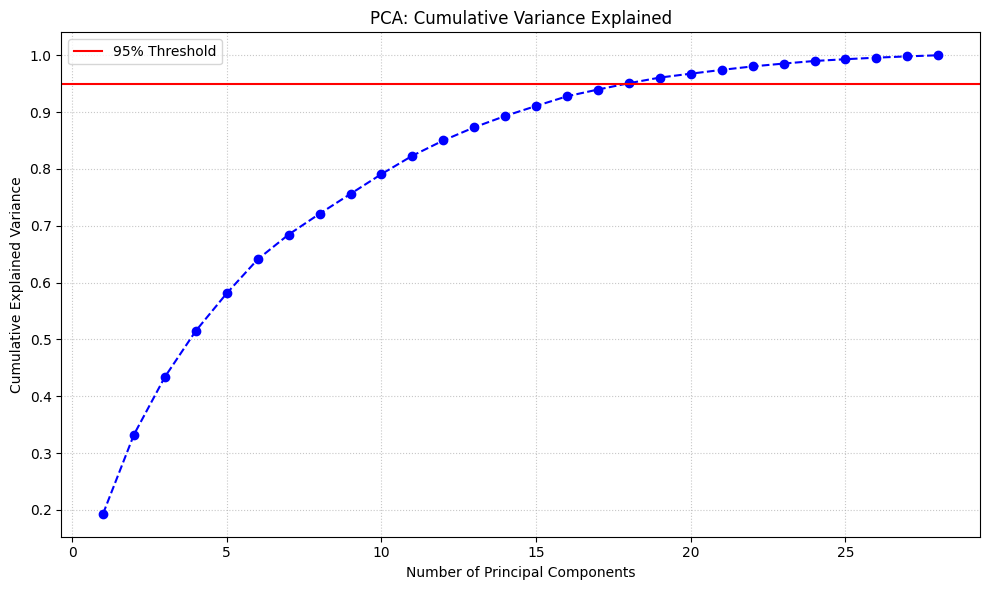

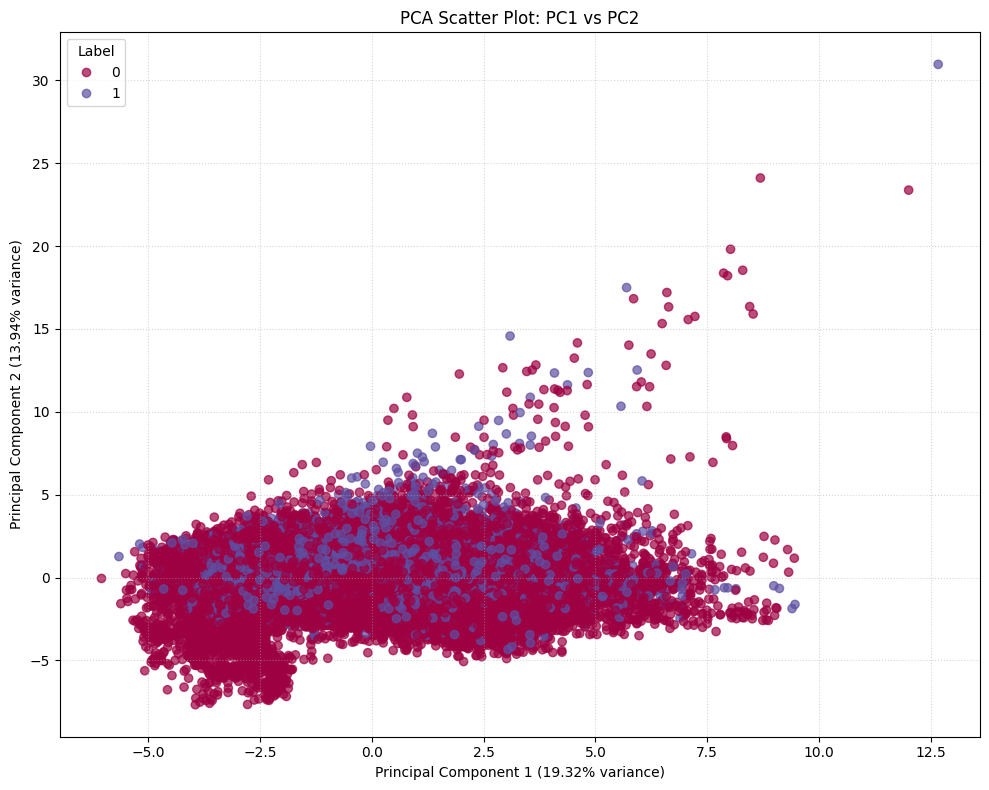

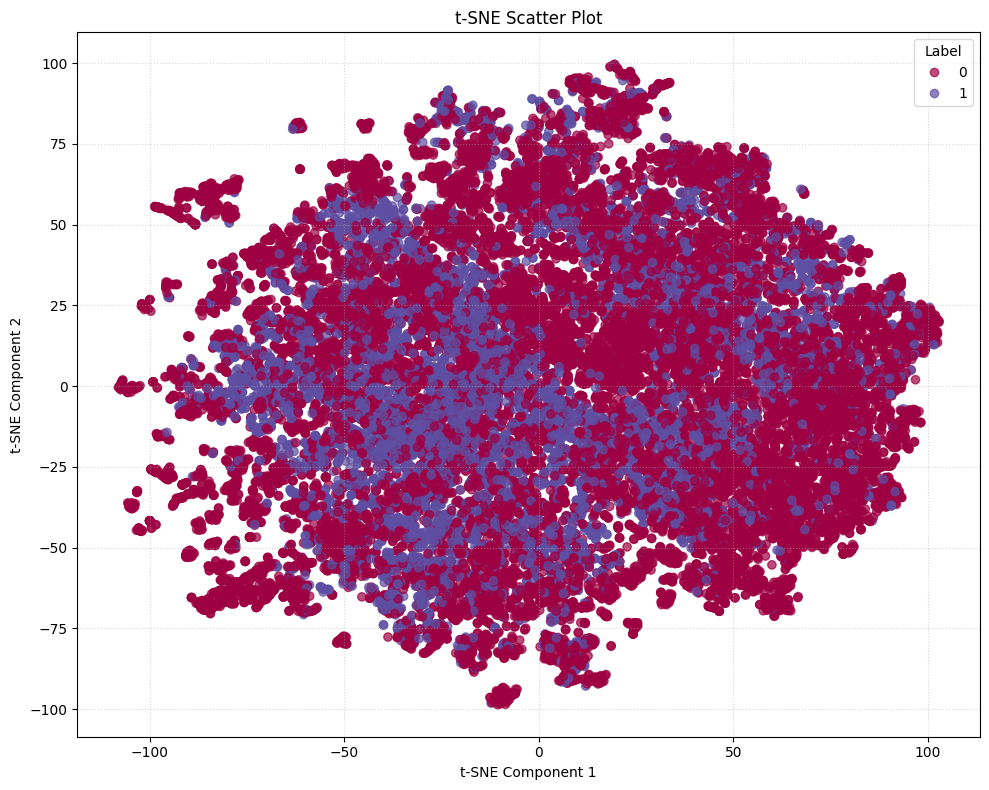

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# ASSUMPTION: df_processed DataFrame is already loaded and contains the columns:
# ['filename', 'grid_index', 'sobel_mean_x', ..., 'saliency_std', 'label']
# -------------------------------------------------------------------

# Columns to exclude from analysis (based on your instructions)
EXCLUDE_COLS = ["filename", "grid_index", "label"]

# Automatically determine the feature columns
feature_cols = [col for col in df_labeled.columns if col not in EXCLUDE_COLS]
df_labeled=df_labeled.dropna()
# Separate features (X) and target (y)
X = df_labeled[feature_cols].copy()
#X=X.dropna()
y = df_labeled['label']

print(f"Starting analysis on {len(feature_cols)} features...")

## 1. Standardize all feature columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features standardized.")

## 2. PCA for Variance Explained and Scatter Plot

# Initialize PCA - keeping all components (or min(n_samples, n_features))
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
df_pca = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['label'] = y.values

# --- Plot 1: Cumulative Variance Explained ---
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('PCA: Cumulative Variance Explained')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle=':', alpha=0.7)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Scatter Plot of the first two Principal Components (PC1 vs PC2) ---
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], 
                      c=pd.factorize(df_pca['label'])[0], 
                      cmap='Spectral', 
                      alpha=0.7)
plt.title('PCA Scatter Plot: PC1 vs PC2')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}% variance)')
# Create legend handles and labels
plt.legend(handles=scatter.legend_elements()[0], labels=y.unique().tolist(), title="Label")
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. t-SNE Scatter Plot

# Initialize and fit t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

# Create a DataFrame for the t-SNE results
df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE_1', 'TSNE_2'])
df_tsne['label'] = y.values

# --- Plot 3: t-SNE Scatter Plot ---
plt.figure(figsize=(10, 8))
tsne_scatter = plt.scatter(df_tsne['TSNE_1'], df_tsne['TSNE_2'], 
                           c=pd.factorize(df_tsne['label'])[0], 
                           cmap='Spectral', 
                           alpha=0.7)
plt.title('t-SNE Scatter Plot')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
# Create legend handles and labels
plt.legend(handles=tsne_scatter.legend_elements()[0], labels=y.unique().tolist(), title="Label")
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [38]:
print( len(df_labeled))

29713


### trying out some frequency level features

In [39]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.fftpack import dct
from numpy.fft import fft2, fftshift
import pywt

# --------------------- helper functions ---------------------
def radial_rings_mask(h, w, num_rings=6):
    cy, cx = h//2, w//2
    Y, X = np.ogrid[:h, :w]
    R = np.sqrt((Y - cy)**2 + (X - cx)**2)
    max_r = R.max()
    edges = np.linspace(0, max_r, num_rings+1)
    masks = [(R >= edges[i]) & (R < edges[i+1]) for i in range(num_rings)]
    return masks

def spectral_entropy(psd, eps=1e-12):
    p = psd.ravel().astype(np.float64)
    p /= (p.sum() + eps)
    p = np.clip(p, a_min=eps, a_max=None)
    return -np.sum(p * np.log2(p))

def fft2_features(gray, num_radial_bins=6):
    gray = gray.astype(np.float32) / 255.0
    h, w = gray.shape
    # apply Hann window to reduce edge effects
    wy = np.hanning(h)[:,None]
    wx = np.hanning(w)[None,:]
    img_win = gray * wy * wx

    F = fftshift(fft2(img_win))
    P = np.abs(F)**2
    masks = radial_rings_mask(h, w, num_rings=num_radial_bins)
    bin_energies = np.array([P[m].sum() for m in masks])
    total_energy = P.sum() + 1e-12
    bin_fracs = bin_energies / total_energy

    Y, X = np.ogrid[:h, :w]
    R = np.sqrt((Y - h//2)**2 + (X - w//2)**2)
    centroid = (R * P).sum() / total_energy
    variance = ((R - centroid)**2 * P).sum() / total_energy
    entropy_val = spectral_entropy(P)
    radial_profile = np.array([P[m].mean() for m in masks])
    dominant_idx = int(radial_profile.argmax())

    low = bin_energies[0]
    mid = bin_energies[1:-1].sum() if num_radial_bins > 3 else bin_energies[1]
    high = bin_energies[-1]
    lf_hf_ratio = (low + 1e-9) / (high + 1e-9)
    mf_hf_ratio = (mid + 1e-9) / (high + 1e-9)

    feats = {}
    for i, val in enumerate(bin_fracs):
        feats[f'fft_bin_frac_{i}'] = float(val)
    feats.update({
        'fft_total_energy': float(total_energy),
        'fft_centroid': float(centroid),
        'fft_spread': float(variance),
        'fft_entropy': float(entropy_val),
        'fft_dom_bin': dominant_idx,
        'fft_lf_hf_ratio': float(lf_hf_ratio),
        'fft_mf_hf_ratio': float(mf_hf_ratio)
    })
    return feats

def dct_low_coeff_energy(gray, keep=(8,8)):
    gray = gray.astype(np.float32)
    dct_cols = dct(gray, type=2, axis=0, norm='ortho')
    dct_2d = dct(dct_cols, type=2, axis=1, norm='ortho')
    kx, ky = keep
    low_block = dct_2d[:ky, :kx]
    total = (dct_2d**2).sum() + 1e-12
    low_energy = (low_block**2).sum()
    return {
        'dct_low_energy': float(low_energy),
        'dct_low_energy_frac': float(low_energy / total)
    }

def dwt_band_energies(gray, wavelet='db1', level=2):
    gray = gray.astype(np.float32)
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)
    energies = {}
    total_energy = 0.0
    for i, c in enumerate(coeffs):
        if i == 0:
            A = c
            e = (A**2).sum()
            energies[f'dwt_A_level{level}'] = float(e)
            total_energy += e
        else:
            cH, cV, cD = c
            eH = (cH**2).sum(); eV = (cV**2).sum(); eD = (cD**2).sum()
            level_id = level - i + 1
            energies[f'dwt_level{level_id}_H'] = float(eH)
            energies[f'dwt_level{level_id}_V'] = float(eV)
            energies[f'dwt_level{level_id}_D'] = float(eD)
            total_energy += eH + eV + eD
    for k in list(energies.keys()):
        energies[k + '_frac'] = float(energies[k] / (total_energy + 1e-12))
    energies['dwt_total_energy'] = float(total_energy)
    return energies

def freq_features_all(gray):
    feats = {}
    feats.update(fft2_features(gray))
    feats.update(dct_low_coeff_energy(gray))
    feats.update(dwt_band_energies(gray))
    return feats

# --------------------- main loop ---------------------
folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\training_blocks"   # <-- change this
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif')

records = []

for fname in tqdm(os.listdir(folder)):
    if fname.lower().endswith(valid_exts):
        path = os.path.join(folder, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        feats = freq_features_all(img)
        feats['filename'] = fname
        records.append(feats)

df_freq = pd.DataFrame(records)
print("✅ Extracted frequency-domain features:", df_freq.shape)
df_freq.to_csv("frequency_features.csv", index=False)
df_freq.head()


100%|███████████████████████████████████████████████████████████████████████████| 29760/29760 [01:19<00:00, 376.36it/s]


✅ Extracted frequency-domain features: (29760, 31)


,fft_bin_frac_0,fft_bin_frac_1,fft_bin_frac_2,fft_bin_frac_3,fft_bin_frac_4,fft_bin_frac_5,fft_total_energy,fft_centroid,fft_spread,fft_entropy,...,dwt_level1_D,dwt_A_level2_frac,dwt_level2_H_frac,dwt_level2_V_frac,dwt_level2_D_frac,dwt_level1_H_frac,dwt_level1_V_frac,dwt_level1_D_frac,dwt_total_energy,filename
0,0.997183,0.001736,0.000807,0.000203,0.000066,0.000006,9.701494e+05,0.681924,1.663734,2.622652,...,4276.250000,0.996666,0.000712,0.000907,0.000358,0.000582,0.000707,0.000068,63308520.0,100820081692-block_0.jpg
1,0.995523,0.002551,0.001350,0.000449,0.000119,0.000009,9.474547e+05,0.724427,2.639086,2.674032,...,5127.500488,0.996072,0.000978,0.000962,0.000318,0.000737,0.000850,0.000083,61606996.0,100820081692-block_1.jpg
2,0.986871,0.009518,0.002432,0.000963,0.000194,0.000022,6.446306e+05,1.141487,6.041341,3.556913,...,13547.498047,0.986356,0.002839,0.005041,0.001052,0.001780,0.002661,0.000270,50175128.0,100820081692-block_10.jpg
3,0.995252,0.002605,0.001437,0.000459,0.000229,0.000018,1.046796e+06,0.741810,3.004773,2.691599,...,12810.998047,0.994270,0.001072,0.001395,0.000534,0.001003,0.001535,0.000191,67151680.0,100820081692-block_11.jpg
4,0.994096,0.003360,0.001756,0.000614,0.000162,0.000012,1.097711e+06,0.755495,3.310753,2.694373,...,13881.250000,0.993974,0.000878,0.001738,0.000625,0.000987,0.001603,0.000196,70910168.0,100820081692-block_12.jpg


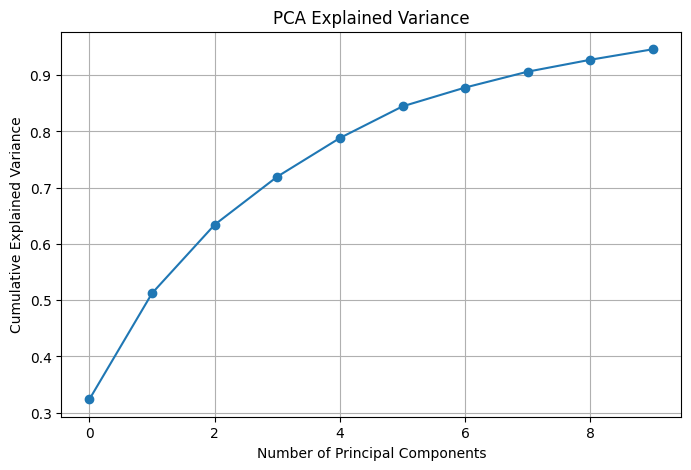

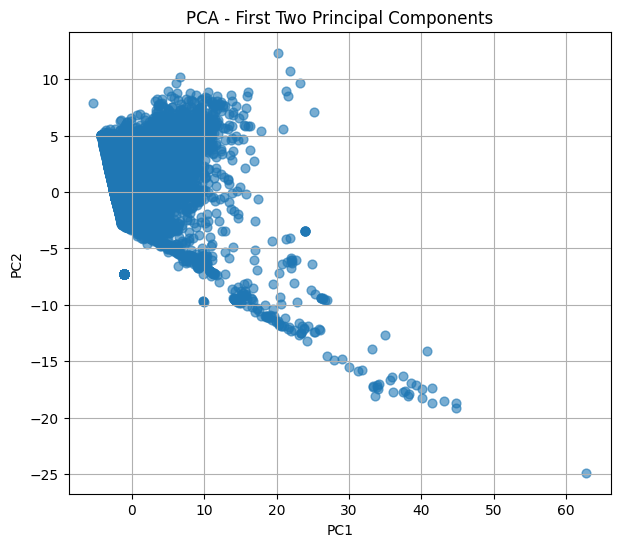

In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming your features dataframe is called `df`
# and that it has a 'filename' column
X = df_freq.drop(columns=['filename']).values

# Standardize features (recommended before PCA)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

# 2D scatter plot for first two principal components
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=40)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - First Two Principal Components')
plt.grid(True)
plt.show()

# Optionally, if you have labels, e.g. df_labels['label']
# you can color by class like this:
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_labels['label'], cmap='coolwarm', alpha=0.7)


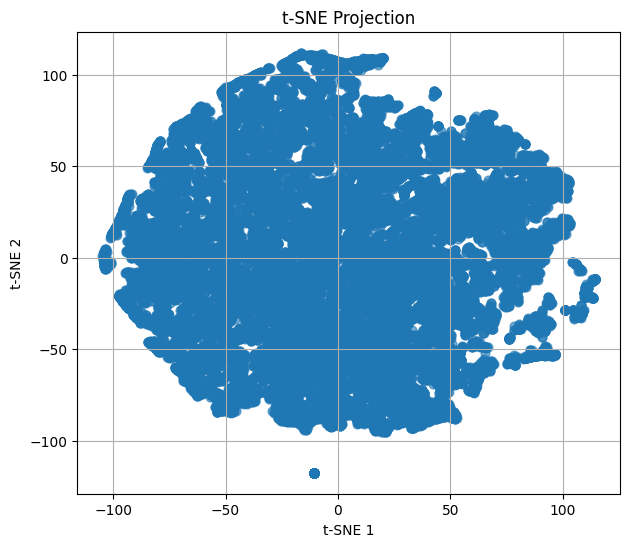

In [43]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# If you already have X_scaled from PCA section
# X_scaled = scaler.fit_transform(X)

# t-SNE (you can tune perplexity if sample size is large)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE
plt.figure(figsize=(7, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=40)
plt.title('t-SNE Projection')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

# Optional: if you have class labels (e.g. df_labels['label'])
# color-code them to check class separation:
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_labels['label'], cmap='coolwarm', alpha=0.7)


In [51]:
# --- Step 1: Normalize both filenames thoroughly ---

def normalize_name(name):
    """Remove path, extension, lowercase, and strip spaces."""
    base = os.path.splitext(os.path.basename(str(name)))[0]
    return base.strip().lower()

df_freq['base_name'] = df_freq['filename'].apply(lambda x: normalize_name(re.sub(r'-block[_-]\d+', '', x)))
df_labeled['base_name'] = df_labeled['filename'].apply(normalize_name)

# --- Step 2: Ensure grid_index is integer ---
df_freq['grid_index'] = pd.to_numeric(df_freq['grid_index'], errors='coerce').astype('Int64')
df_labeled['grid_index'] = pd.to_numeric(df_labeled['grid_index'], errors='coerce').astype('Int64')

# --- Step 3: Merge ---
df_merged = pd.merge(
    df_freq,
    df_labeled[['base_name', 'grid_index', 'label']],
    on=['base_name', 'grid_index'],
    how='left'
)

# --- Step 4: Report ---
print("✅ Merged dataframe shape:", df_merged.shape)
print("✅ Labeled rows:", df_merged['label'].notna().sum(), "/", len(df_merged))
print(df_merged[['filename', 'grid_index', 'label']].head())

# --- Optional: Check sample of unmatched files ---
unmatched = df_merged[df_merged['label'].isna()]
if len(unmatched) > 0:
    print("\n⚠️ Still unmatched (showing first few):")
    print(unmatched[['filename', 'grid_index']].head())
    # Show what corresponding df_labeled base names look like for comparison
    print("\nExample df_labeled base names:", df_labeled['base_name'].unique()[:10])
else:
    print("\n🎯 All rows matched with a label.")


✅ Merged dataframe shape: (29760, 34)
✅ Labeled rows: 29713 / 29760
                    filename  grid_index  label
0   100820081692-block_0.jpg           0    0.0
1   100820081692-block_1.jpg           1    0.0
2  100820081692-block_10.jpg          10    1.0
3  100820081692-block_11.jpg          11    0.0
4  100820081692-block_12.jpg          12    0.0

⚠️ Still unmatched (showing first few):
                   filename  grid_index
1460  CIMG0029-block_56.JPG          56
1544  CIMG0034-block_16.JPG          16
1553  CIMG0034-block_24.JPG          24
1562  CIMG0034-block_32.JPG          32
1571  CIMG0034-block_40.JPG          40

Example df_labeled base names: ['img_20180726_154742802' 'img_20250709_164054571_hdr~2' 'p12'
 'img_20250705_125546309' 'img_20250709_163052484_hdr~2'
 'img_20250709_164031681_hdr~2' '29032008693' 'p10' 'img_20250705_142522'
 'img_20221207_075613681']


✅ Using 30 numeric features for PCA/t-SNE


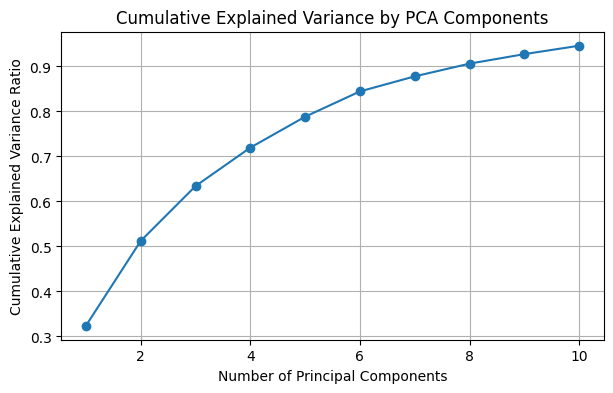

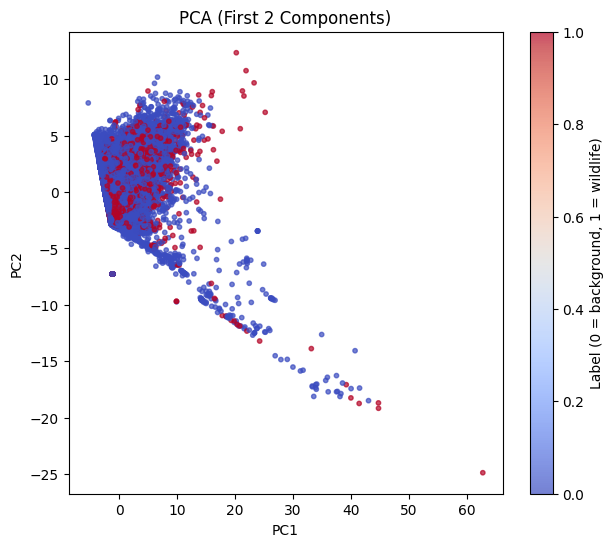

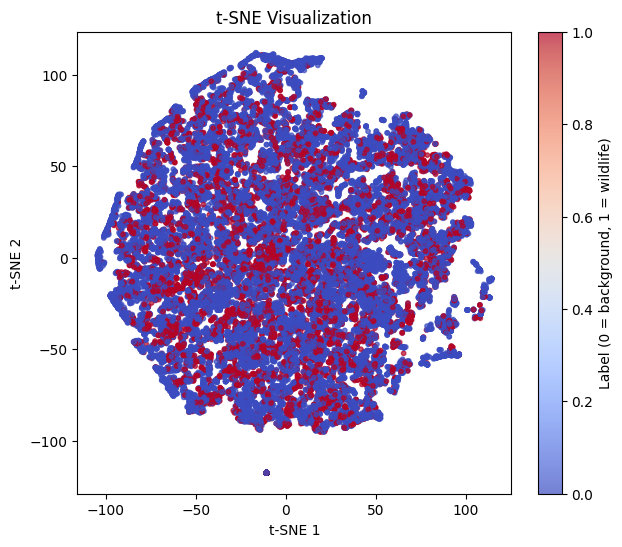

In [55]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Step 1: Keep only numeric columns as features ---
numeric_cols = df_merged.select_dtypes(include=['number']).columns
feature_cols = [col for col in numeric_cols if col not in ['label', 'grid_index']]
X = df_merged[feature_cols].values
y = df_merged['label'].values

print("✅ Using", len(feature_cols), "numeric features for PCA/t-SNE")

# --- Step 2: Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 3: PCA ---
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# --- Step 4: Explained variance plot ---
plt.figure(figsize=(7,4))
plt.plot(range(1, 11), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True)
plt.show()

# --- Step 5: PCA scatter ---
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=10, alpha=0.7)
plt.title("PCA (First 2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Label (0 = background, 1 = wildlife)")
plt.show()

# --- Step 6: t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

# --- Step 7: t-SNE scatter ---
plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', s=10, alpha=0.7)
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Label (0 = background, 1 = wildlife)")
plt.show()



### HOG"\

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import hog

# === CONFIG ===
images_folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\training_blocks"
output_csv = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features.csv"

# === Parameters ===
target_size = (100, 75)  # width x height
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)

# === Storage ===
records = []

# === Loop over all images ===
for fname in os.listdir(images_folder):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(images_folder, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray_resized = cv2.resize(gray, target_size)

        # Compute HOG features
        features = hog(
            gray_resized,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )

        records.append([fname] + list(features))

# === Create DataFrame ===
# Dynamically name feature columns as hog_0, hog_1, ...
columns = ['filename'] + [f'hog_{i}' for i in range(len(records[0]) - 1)]
hog_df = pd.DataFrame(records, columns=columns)

# === Save to CSV ===
hog_df.to_csv(output_csv, index=False)
print(f"✅ HOG feature extraction complete. Saved {len(hog_df)} rows to {output_csv}")
print(f"Each image has {len(hog_df.columns)-1} HOG features.")


✅ HOG feature extraction complete. Saved 29760 rows to C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features.csv
Each image has 3168 HOG features.


In [2]:
import pandas as pd

# === CONFIG ===
hog_csv = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features.csv"
labels_xlsx = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\dino_clusters.xlsx"
output_csv = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features_with_labels.csv"

# === Load both files ===
hog_df = pd.read_csv(hog_csv)
labels_df = pd.read_excel(labels_xlsx, dtype=str)

# Clean up filenames (remove extensions if any)
labels_df.rename(columns={labels_df.columns[0]: 'filename'}, inplace=True)
labels_df['filename'] = (
    labels_df['filename']
    .astype(str)
    .str.strip()
    .str.replace(r'\.(jpg|jpeg|png)$', '', case=False, regex=True)
)

# Extract base filename and block number from HOG df
hog_df['base_name'] = hog_df['filename'].str.extract(r'^(.*?)-block_')[0]
hog_df['block_no'] = hog_df['filename'].str.extract(r'block_(\d+)').astype(int)

# Fetch label from Excel
def get_label(row):
    fname = row['base_name']
    block_col = f'block_{row["block_no"]}'
    match = labels_df[labels_df['filename'] == fname]
    if not match.empty and block_col in match.columns:
        return match.iloc[0][block_col]
    else:
        return None

hog_df['label'] = hog_df.apply(get_label, axis=1)

# Drop helper columns if you want
final_df = hog_df.drop(columns=['base_name', 'block_no'])

# Save final dataset
final_df.to_csv(output_csv, index=False)
print(f"✅ Merged labels. Saved {len(final_df)} rows to {output_csv}")
print(final_df.head(3))


✅ Merged labels. Saved 29760 rows to C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features_with_labels.csv
                    filename     hog_0     hog_1     hog_2     hog_3  \
0   100820081692-block_0.jpg  0.250812  0.090444  0.000000  0.104096   
1   100820081692-block_1.jpg  0.139233  0.080397  0.064643  0.149525   
2  100820081692-block_10.jpg  0.241926  0.241926  0.128241  0.097704   

      hog_4     hog_5     hog_6     hog_7     hog_8  ...  hog_3159  hog_3160  \
0  0.250812  0.239571  0.167729  0.132606  0.250812  ...  0.114209  0.061496   
1  0.210195  0.063906  0.192122  0.104552  0.111530  ...  0.241771  0.241771   
2  0.241926  0.063052  0.104196  0.081856  0.111337  ...  0.088354  0.096435   

   hog_3161  hog_3162  hog_3163  hog_3164  hog_3165  hog_3166  hog_3167  label  
0   0.19908  0.236055  0.236055  0.236055  0.188582  0.098616  0.130046      0  
1   0.11867  0.178048  0.086704  0.143322  0.050276  0.241771  0.110418      0  
2   0.07081  0.134278  0.22200

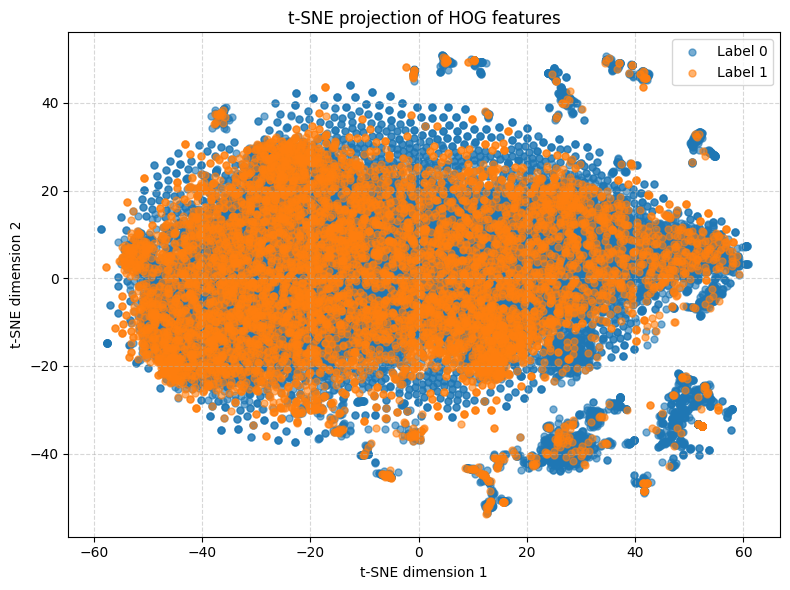

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# === CONFIG ===
csv_path = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features_with_labels.csv"

# === Load dataset ===
df = pd.read_csv(csv_path)

# === Separate features and labels ===
# Exclude filename and label columns
feature_cols = [c for c in df.columns if c not in ['filename', 'label']]
X = df[feature_cols].values
y = df['label'].astype(int).values  # ensure numeric

# === Standardize the features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Compute t-SNE ===
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

# === Plot ===
plt.figure(figsize=(8,6))
plt.scatter(
    X_embedded[y == 0, 0],
    X_embedded[y == 0, 1],
    label='Label 0',
    alpha=0.6,
    s=25
)
plt.scatter(
    X_embedded[y == 1, 0],
    X_embedded[y == 1, 1],
    label='Label 1',
    alpha=0.6,
    s=25
)

plt.title('t-SNE projection of HOG features')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
)

# === Load Data ===
csv_path = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features_with_labels.csv"
df = pd.read_csv(csv_path)

# === Separate features & labels ===
feature_cols = [c for c in df.columns if c not in ['filename', 'label']]
X = df[feature_cols].values
y = df['label'].astype(int).values

# === Split into train & test ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# === Standardize ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Train Random Forest ===
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# === Predictions ===
y_pred = rf.predict(X_test_scaled)
y_prob = rf.predict_proba(X_test_scaled)[:, 1]  # for ROC-AUC

# === Metrics ===
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# === Print Results ===
print("=== Random Forest Performance ===")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

# Optional: print confusion matrix & detailed report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))


=== Random Forest Performance ===
Accuracy : 0.777
Precision: 0.661
Recall   : 0.097
F1 Score : 0.169
ROC-AUC  : 0.771

Confusion Matrix:
[[5615   86]
 [1571  168]]

Classification Report:
              precision    recall  f1-score   support

           0      0.781     0.985     0.871      5701
           1      0.661     0.097     0.169      1739

    accuracy                          0.777      7440
   macro avg      0.721     0.541     0.520      7440
weighted avg      0.753     0.777     0.707      7440



In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# === Load the dataset ===
data = pd.read_csv(r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\hog_features_with_labels.csv")

# Drop non-numeric columns (like filenames)
non_feature_cols = ['filename', 'block', 'label']
X = data.drop(columns=[col for col in non_feature_cols if col in data.columns])
y = data['label']

# Ensure X is numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)  # replace any missing/NaN values

# === Split into train/test ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# === Standardize the features ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === Build a simple Neural Network ===
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# === Train the model ===
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# === Evaluate on test set ===
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# === Metrics ===
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC Score: {auc:.4f}")


C:\Users\Rohan\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7247 - loss: 0.6351 - val_accuracy: 0.7715 - val_loss: 0.4901
Epoch 2/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7896 - loss: 0.4672 - val_accuracy: 0.7711 - val_loss: 0.4770
Epoch 3/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8001 - loss: 0.4422 - val_accuracy: 0.7753 - val_loss: 0.4837
Epoch 4/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8107 - loss: 0.4167 - val_accuracy: 0.7734 - val_loss: 0.4925
Epoch 5/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8289 - loss: 0.3841 - val_accuracy: 0.7759 - val_loss: 0.4913
Epoch 6/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8434 - loss: 0.3622 - val_accuracy: 0.7768 - val_loss: 0.4870
Epoch 7/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8531 - loss: 0.3370 - val_accuracy: 0.7774 - val_loss: 0.5158
Epoch 8/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8731 - loss: 0.3041 - val_accuracy:

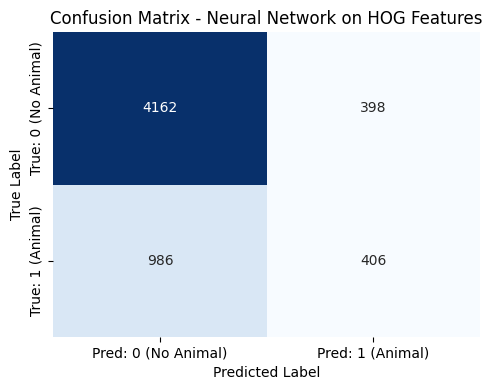

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# === Compute confusion matrix ===
cm = confusion_matrix(y_test, y_pred)

# === Plot it ===
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: 0 (No Animal)', 'Pred: 1 (Animal)'],
            yticklabels=['True: 0 (No Animal)', 'True: 1 (Animal)'])
plt.title('Confusion Matrix - Neural Network on HOG Features')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# === Adjust these paths ===
image_folder = r"C:\Users\Rohan\Desktop\3rd_sem\DS203\Final_project\DS203-2025-S1-E7-project-images\Scaled_images"  # folder containing original images
block_w, block_h = 75, 100  # block size used earlier

# --- Ensure we know which column has filenames ---
# Replace this with your test dataframe (or re-read CSV if needed)
# test_meta = df_test.copy() or pd.read_csv("test_meta.csv")

# Try to identify filename column automatically
possible_cols = [c for c in test_meta.columns if "file" in c.lower()]
if possible_cols:
    file_col = possible_cols[0]
else:
    file_col = test_meta.columns[0]  # fallback
print(f"✅ Using '{file_col}' as filename column")

# --- Extract filename and block number from '<filename>-block_<n>' format ---
test_meta = test_meta.copy()
test_meta['filename'] = test_meta[file_col].apply(lambda x: x.split('-block_')[0])
test_meta['block_no'] = test_meta[file_col].apply(
    lambda x: int(x.split('-block_')[1].split('.')[0]) if '-block_' in x else 0
)

# --- Add predictions ---
test_meta['pred_label'] = y_pred  # ensure y_pred corresponds to test set order

# --- Function to reconstruct and visualize ---
def reconstruct_image_blocks(fname, df_img, save_dir="reconstructed"):
    os.makedirs(save_dir, exist_ok=True)

    img_path = os.path.join(image_folder, fname + ".jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(image_folder, fname + ".png")
    if not os.path.exists(img_path):
        print(f"⚠️ Image {fname} not found, skipping.")
        return

    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not load {fname}, skipping.")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape
    n_blocks_x = w // block_w
    n_blocks_y = h // block_h

    overlay = img.copy()
    for _, row in df_img.iterrows():
        block_idx = row['block_no']
        pred = row['pred_label']

        by = block_idx // n_blocks_x
        bx = block_idx % n_blocks_x

        x1, y1 = bx * block_w, by * block_h
        x2, y2 = x1 + block_w, y1 + block_h

        if pred == 1:  # mark "animal" prediction
            cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Blend overlay for visibility
    blended = cv2.addWeighted(overlay, 0.6, img, 0.4, 0)

    plt.figure(figsize=(8, 6))
    plt.imshow(blended)
    plt.title(f"Predicted Animal Blocks - {fname}")
    plt.axis("off")
    plt.show()

    cv2.imwrite(os.path.join(save_dir, fname + "_predicted.jpg"), cv2.cvtColor(blended, cv2.COLOR_RGB2BGR))

# --- Loop over all unique filenames ---
for fname in tqdm(test_meta['filename'].unique()):
    df_img = test_meta[test_meta['filename'] == fname]
    reconstruct_image_blocks(fname, df_img)


✅ Using 'y_true' as filename column


AttributeError: 'int' object has no attribute 'split'

Before SMOTE: [18242  5566]
After SMOTE: [18242 18242]


C:\Users\Rohan\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6336 - loss: 0.7291 - val_accuracy: 0.7129 - val_loss: 0.5789
Epoch 2/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7791 - loss: 0.4649 - val_accuracy: 0.7466 - val_loss: 0.5336
Epoch 3/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8304 - loss: 0.3779 - val_accuracy: 0.7354 - val_loss: 0.5537
Epoch 4/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8545 - loss: 0.3237 - val_accuracy: 0.7463 - val_loss: 0.5791
Epoch 5/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8759 - loss: 0.2815 - val_accuracy: 0.7550 - val_loss: 0.6302
Epoch 6/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8867 - loss: 0.2647 - val_accuracy: 0.7567 - val_loss: 0.6293
Epoch 7/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8998 - loss: 0.2368 - val_accuracy: 0.7599 - val_loss: 0.6936
Epoch 8/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9113 - loss: 0.2122 - val_accu

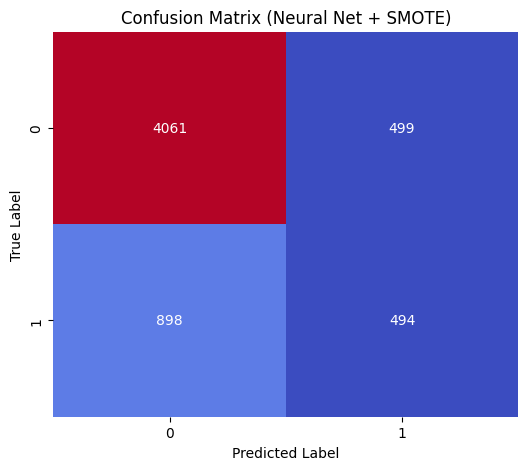

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import matplotlib.pyplot as plt

# === Load HOG features dataframe ===
# df = pd.read_csv("hog_features_with_labels.csv")

# --- Separate features and label ---
X = df.drop(columns=["filename", "label"]).values
y = df["label"].astype(int).values

# --- Split into train/test sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Handle imbalance using SMOTE ---
print("Before SMOTE:", np.bincount(y_train))
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", np.bincount(y_train_res))

# --- Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# --- Define simple Neural Network ---
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- Train the model ---
history = model.fit(
    X_train_scaled, y_train_res,
    validation_data=(X_test_scaled, y_test),
    epochs=25,
    batch_size=64,
    verbose=1
)

# --- Predictions and Evaluation ---
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# --- Print classification metrics ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# --- Confusion matrix plot ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Neural Net + SMOTE)')
plt.show()

